In [13]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [14]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [ ]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9
GHz = 1e9

## Specifying the device and solver dimensions and params ##

In [16]:
## device dimensions

W1 = 1.48*um
W2 = 1.48*um
W3 = 1.6*um
W4 = 0.5*um
W5 = 0.7*um
W6 = 0.2*um
L1 = 1*um
L2 = 2.4*um
L3 = 1.6*um
H = 220*nm
R = 4*um
L = 2.4*um
dL = L/12
L_Y = L + 12*dL
L_rects = 2*um

## materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

## solver:

x_min_fdtd = -(2*(L1 + L2 + L3) + R + 3/4*L_rects)
x_max_fdtd = 2*(L1 + L2 + L3) + R + 3/4*L_rects
y_min_fdtd = -(2*(L1 + L2 + L3) + R + 3/4*L_rects)
y_max_fdtd = L_Y + R + 3/4*L_rects
z_span_fdtd = 3*H

simulation_time = 5*(4*(L1 + L2 + L3) + 2*R + 2*L_rects)/c

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy = 4

indxLambda = 24

### Building the device ###

In [17]:
fdtdApi.addstructuregroup()
fdtdApi.set('name', 'group')
gds_file_1 = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90_optical_hybrid/Compact_Y_Branch_2.gds"
gds_file_2 = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90_optical_hybrid/MMI2X2.gds"

In [18]:
#principal device:

fdtdApi.gdsimport(gds_file_2, 'TOP', '1:0')
fdtdApi.set('name', 'bottom_MMI')
fdtdApi.set('x', 0)
fdtdApi.set('y', 0)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.gdsimport(gds_file_2, 'TOP', '1:0')
fdtdApi.set('name', 'right_MMI')
fdtdApi.set('material', material)
fdtdApi.set('x',  -L1 - L2 - L3 - R - W5/2 - W6/2)
fdtdApi.set('y', W5/2 + W6/2 + R + L1 + L2 + L3)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('first axis', 'z')
fdtdApi.set('rotation 1', 90)
fdtdApi.addtogroup('group')

fdtdApi.gdsimport(gds_file_2, 'TOP', '1:0')
fdtdApi.set('name', 'left_MMI')
fdtdApi.set('material', material)
fdtdApi.set('x', -L1 - L2 - L3 - R - W5/2 - W6/2)
fdtdApi.set('y', -W5/2 - W6/2 - R - L1 - L2 - L3)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('first axis', 'z')
fdtdApi.set('rotation 1', -90)
fdtdApi.addtogroup('group')

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', 'bend_1')
fdtdApi.set('radius', R)
fdtdApi.set('base height', H)
fdtdApi.set('base width', W4)
fdtdApi.set('x', -L1 - L2 - L3 - 2*R - W5 - W6)
fdtdApi.set('y', W5/2 + W6/2 + R)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('rotation 1', 180)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', 'bend_2')
fdtdApi.set('radius', R)
fdtdApi.set('base height', H)
fdtdApi.set('base width', W4)
fdtdApi.set('x', -L1 - L2 - L3 - 2*R - W5 - W6)
fdtdApi.set('y', -W5/2 - W6/2 - R)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('rotation 1', 0)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', 'bend_3')
fdtdApi.set('radius', R)
fdtdApi.set('base height', H)
fdtdApi.set('base width', W4)
fdtdApi.set('x', -L1 - L2 - L3)
fdtdApi.set('y', W5/2 + W6/2 + R)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('second axis', 'y')
fdtdApi.set('rotation 1', 180)
fdtdApi.set('rotation 2', 180)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', 'bend_4')
fdtdApi.set('radius', R)
fdtdApi.set('base height', H)
fdtdApi.set('base width', W4)
fdtdApi.set('x', -L1 - L2 - L3)
fdtdApi.set('y', -W5/2 - W6/2 - R)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('second axis', 'y')
fdtdApi.set('rotation 1', 0)
fdtdApi.set('rotation 2', 180)
fdtdApi.set('material', material)

fdtdApi.gdsimport(gds_file_1, 'model', '1:0')
fdtdApi.set('name', 'Y_branch')
fdtdApi.set('x', -L1 - L2 - L3 - 2*R - W5 - W6 - L_Y/2)
fdtdApi.set('y', 0)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

#auxiliary rectangles and bends:

fdtdApi.addrect()
fdtdApi.set('name', 'LO')
fdtdApi.set('x', -L1 - L2 - L3 - 2*R - W5 - W6 - L_Y - L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W4)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'Signal')
fdtdApi.set('x', L1 + L2 + L3 + L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', -(W5 + W6)/2)
fdtdApi.set('y span', W4)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_without_signal')
fdtdApi.set('x', L1 + L2 + L3 + L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', (W5 + W6)/2)
fdtdApi.set('y span', W4)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'Ch-1, Qp')
fdtdApi.set('x', -L1 - L2 - L3 - R)
fdtdApi.set('x span', W4)
fdtdApi.set('y', -W5/2 - W6/2 - R - 2*L1 - 2*L2 - 2*L3 - L_rects/2)
fdtdApi.set('y span', L_rects)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'Ch-2, Qn')
fdtdApi.set('x', -L1 - L2 - L3 - R - W5 - W6)
fdtdApi.set('x span', W4)
fdtdApi.set('y', -W5/2 - W6/2 - R - 2*L1 - 2*L2 - 2*L3 - L_rects/2)
fdtdApi.set('y span', L_rects)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'Ch-3, In')
fdtdApi.set('x', -L1 - L2 - L3 - R - W5 - W6)
fdtdApi.set('x span', W4)
fdtdApi.set('y', W5/2 + W6/2 + R + 2*L1 + 2*L2 + 2*L3 + L_rects/2)
fdtdApi.set('y span', L_rects)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'Ch-4, Ip')
fdtdApi.set('x', -L1 - L2 - L3 - R)
fdtdApi.set('x span', W4)
fdtdApi.set('y', W5/2 + W6/2 + R + 2*L1 + 2*L2 + 2*L3 + L_rects/2)
fdtdApi.set('y span', L_rects)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

In [19]:
fdtdApi.select('group')
fdtdApi.set('first axis', 'z')
fdtdApi.set('rotation 1', 270)
fdtdApi.set('y', -L1 - L2 - L3 - R - W5/2 - W6/2)

### Add the solver and monitors ###

In [20]:
fdtdApi.addfdtd()

fdtdApi.set('x min', x_min_fdtd)
fdtdApi.set('x max', x_max_fdtd)
fdtdApi.set('y min', y_min_fdtd)
fdtdApi.set('y max', y_max_fdtd)
fdtdApi.set('z', 0)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('simulation time', simulation_time)

## add ports

fdtdApi.addport()
fdtdApi.set('name', 'LO port')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', 0)
fdtdApi.set('x span', W5 + 0.65*W6)
fdtdApi.set('y', y_max_fdtd - 1.5*dL)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'Signal port')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -(W5+W6)/2)
fdtdApi.set('x span', W5 + 0.65*W6)
fdtdApi.set('y', y_min_fdtd + 1.5*dL)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'port without signal')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', (W5+W6)/2)
fdtdApi.set('x span', W5 + 0.65*W6)
fdtdApi.set('y', y_min_fdtd + 1.5*dL)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'Qp port')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', x_min_fdtd + 1.5*dL)
fdtdApi.set('y', -(W5+W6)/2)
fdtdApi.set('y span', W5 + 0.65*W6)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'Qn port')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', x_min_fdtd + 1.5*dL)
fdtdApi.set('y', (W5+W6)/2)
fdtdApi.set('y span', W5 + 0.65*W6)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'In port')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', x_max_fdtd - 1.5*dL)
fdtdApi.set('y', (W5+W6)/2)
fdtdApi.set('y span', W5 + 0.65*W6)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'Ip port')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', x_max_fdtd - 1.5*dL)
fdtdApi.set('y', -(W5+W6)/2)
fdtdApi.set('y span', W5 + 0.65*W6)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

## add moniors 

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x min', x_min_fdtd)
fdtdApi.set('x max', x_max_fdtd)
fdtdApi.set('y min', y_min_fdtd)
fdtdApi.set('y max', y_max_fdtd)
fdtdApi.set('z', 0)

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set('x min', x_min_fdtd)
fdtdApi.set('x max', x_max_fdtd)
fdtdApi.set('y min', y_min_fdtd)
fdtdApi.set('y max', y_max_fdtd)
fdtdApi.set('z', 0)

## saving

fdtdApi.setdevice('GPU')
fdtdApi.save('90 optical hybrid')

# analyzing the device's behavior  #

In [21]:
def CMRR(P1, P2): #P1 -> port p, P2 -> port n
    CMRR_linear = np.abs((P1 - P2)/(P1 + P2))
    return -20*np.log10(CMRR_linear)

def Imbalance(P1, P2):
    Imbalance_linear = np.abs(P1/P2)
    return 10*np.log10(Imbalance_linear)

### Input in the signal port ###

In [22]:
fdtdApi.setnamed('FDTD::ports', 'source port', 'Signal port')

In [23]:
fdtdApi.run()

In [24]:
index_x = np.squeeze(fdtdApi.getdata('index', 'index_x').real)
x_device = np.squeeze(fdtdApi.getdata('index', 'x'))/um
y_device = np.squeeze(fdtdApi.getdata('index', 'y'))/um

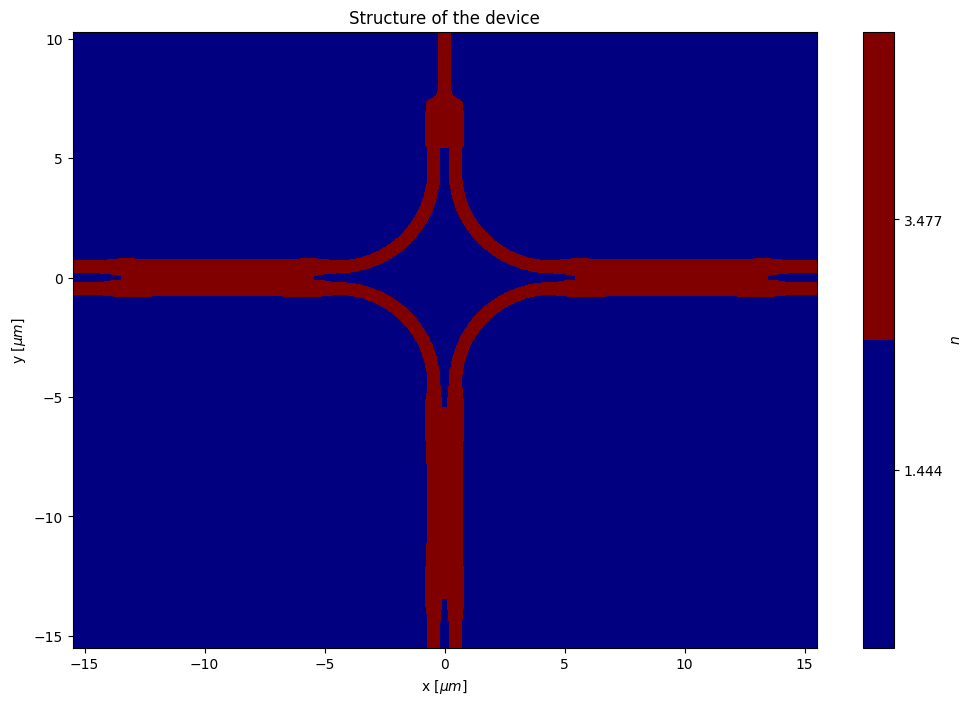

In [25]:
X, Y = np.meshgrid(x_device, y_device)
X, Y = np.transpose(X), np.transpose(Y)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

fig0 = plt.figure(figsize=(12,8))
im0 = plt.contourf(X, Y, index_x, 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im0, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'x [$\mu m$]')
plt.ylabel(r'y [$\mu m$]')
plt.title('Structure of the device')

plt.show()

In [26]:
eField_x = np.squeeze(fdtdApi.getdata('profile_xy', 'Ex'))
eField_y = np.squeeze(fdtdApi.getdata('profile_xy', 'Ey'))
eField_z = np.squeeze(fdtdApi.getdata('profile_xy', 'Ez'))

eField_abs2_Signal = np.abs(eField_x)**2 + np.abs(eField_y)**2 + np.abs(eField_z)**2
eField_abs_Signal = np.sqrt(eField_abs2_Signal)

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

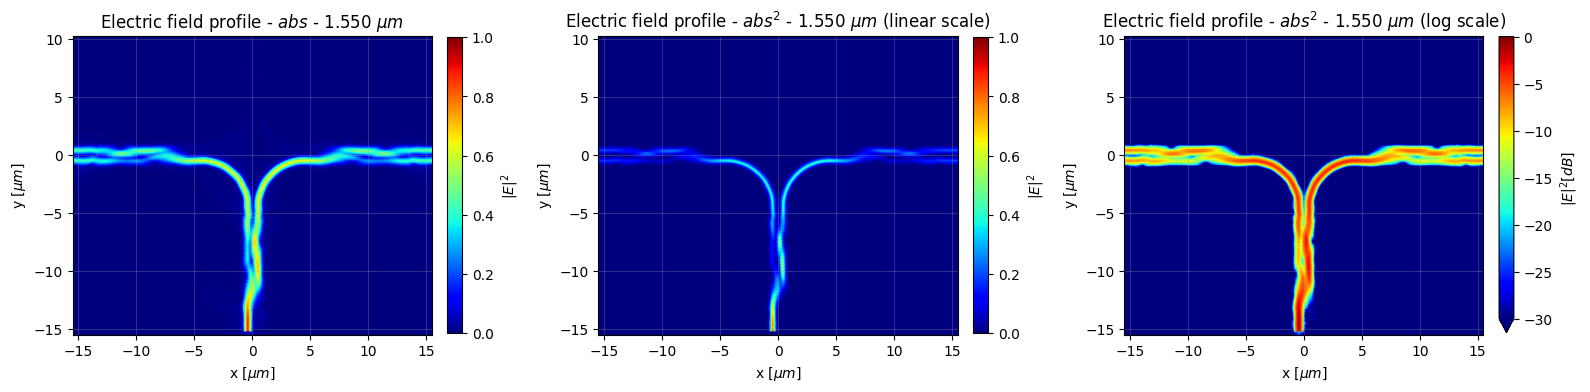

In [27]:
fig1, ax1 = plt.subplots(1,3,figsize=(16,4))

im1 = ax1[0].imshow(np.rot90(eField_abs_Signal[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
#ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im1,fraction = 0.038, pad =0.04, label = r'$|E|^2$')

ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'Electric field profile - $abs$ - %4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax1[0].grid(which='major', alpha = 0.25)

im2 = ax1[1].imshow(np.rot90(eField_abs2_Signal[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im2,fraction = 0.038, pad =0.04, label = r'$|E|^2$')

ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[1].grid(which='major', alpha = 0.25)

im3 = ax1[2].imshow(np.rot90(10*np.log10(eField_abs2_Signal[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = 'jet', aspect = 'equal')

colorbar = plt.colorbar(im3, fraction = 0.038, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax1[2].set_xlabel(r'x [$\mu m$]')
ax1[2].set_ylabel(r'y [$\mu m$]')
ax1[2].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[2].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

In [28]:
## Extracting the ports data

input_Signal = np.abs(fdtdApi.getresult('FDTD::ports::Signal port', 'T')['T'])
P_port_Qp_Signal = np.abs(fdtdApi.getresult('FDTD::ports::Qp port', 'T')['T'])
P_port_Qn_Signal = np.abs(fdtdApi.getresult('FDTD::ports::Qn port', 'T')['T'])
P_port_In_Signal = np.abs(fdtdApi.getresult('FDTD::ports::In port', 'T')['T'])
P_port_Ip_Signal = np.abs(fdtdApi.getresult('FDTD::ports::Ip port', 'T')['T'])

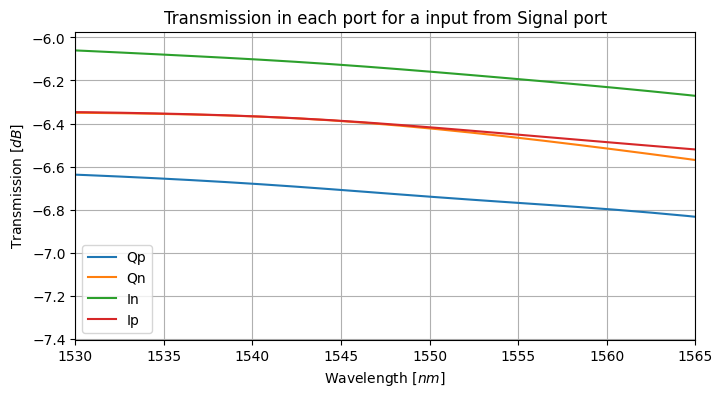

In [29]:
ports_list = [P_port_Qp_Signal, P_port_Qn_Signal, P_port_In_Signal, P_port_Ip_Signal]
name_port_list = ['Qp', 'Qn', 'In', 'Ip']

k = 0
for port in ports_list:
    T_dB = 10*(np.log10(port) - np.log10(input_Signal))
    plt.plot(central_wavelength/nm, T_dB, label = name_port_list[k])
    k += 1

plt.xlabel(r'Wavelength [$nm$]')
plt.ylabel(r'Transmission [$dB$]')
plt.xlim([1530, 1565])
plt.legend(loc = 'best')
plt.grid(True)
plt.title('Transmission in each port for a input from Signal port')
plt.show()

### input in the LO port ###

In [30]:
fdtdApi.switchtolayout()
fdtdApi.setnamed('FDTD::ports', 'source port', 'LO port')

In [31]:
fdtdApi.run()

In [32]:
eField_x = np.squeeze(fdtdApi.getdata('profile_xy', 'Ex'))
eField_y = np.squeeze(fdtdApi.getdata('profile_xy', 'Ey'))
eField_z = np.squeeze(fdtdApi.getdata('profile_xy', 'Ez'))

eField_abs2_LO = np.abs(eField_x)**2 + np.abs(eField_y)**2 + np.abs(eField_z)**2
eField_abs_LO = np.sqrt(eField_abs2_LO)

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

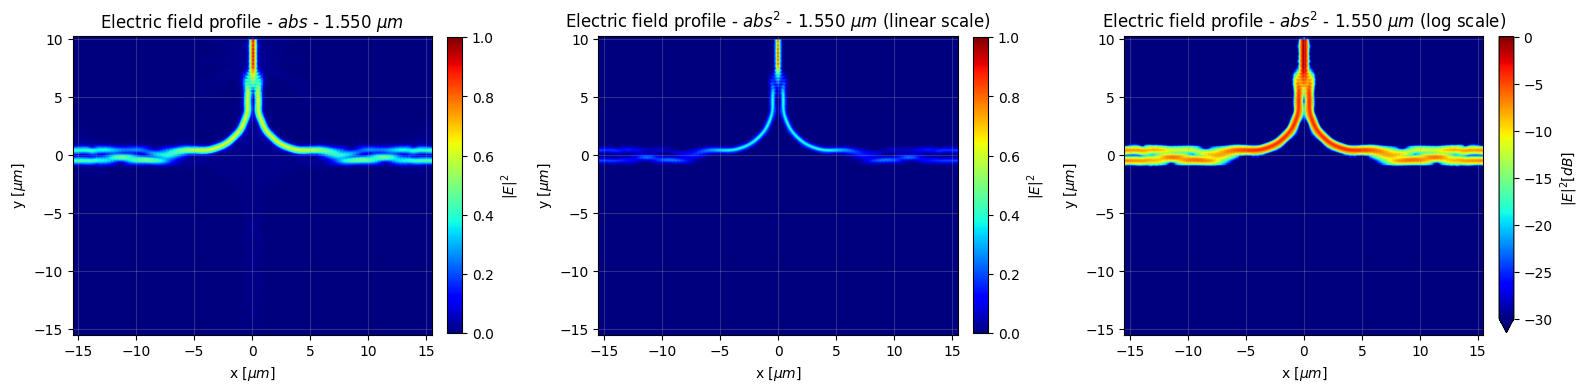

In [33]:
fig2, ax2 = plt.subplots(1,3,figsize=(16,4))

im1 = ax2[0].imshow(np.rot90(eField_abs_LO[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
#ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im1,fraction = 0.038, pad =0.04, label = r'$|E|^2$')

ax2[0].set_xlabel(r'x [$\mu m$]')
ax2[0].set_ylabel(r'y [$\mu m$]')
ax2[0].set_title(r'Electric field profile - $abs$ - %4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax2[0].grid(which='major', alpha = 0.25)

im2 = ax2[1].imshow(np.rot90(eField_abs2_LO[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im2,fraction = 0.038, pad =0.04, label = r'$|E|^2$')

ax2[1].set_xlabel(r'x [$\mu m$]')
ax2[1].set_ylabel(r'y [$\mu m$]')
ax2[1].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax2[1].grid(which='major', alpha = 0.25)

im3 = ax2[2].imshow(np.rot90(10*np.log10(eField_abs2_LO[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = 'jet', aspect = 'equal')

colorbar = plt.colorbar(im3, fraction = 0.038, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax2[2].set_xlabel(r'x [$\mu m$]')
ax2[2].set_ylabel(r'y [$\mu m$]')
ax2[2].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax2[2].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

In [34]:
## Extracting the ports data

input_LO = np.abs(fdtdApi.getresult('FDTD::ports::LO port', 'T')['T'])
P_port_Qp_LO = np.abs(fdtdApi.getresult('FDTD::ports::Qp port', 'T')['T'])
P_port_Qn_LO = np.abs(fdtdApi.getresult('FDTD::ports::Qn port', 'T')['T'])
P_port_In_LO = np.abs(fdtdApi.getresult('FDTD::ports::In port', 'T')['T'])
P_port_Ip_LO = np.abs(fdtdApi.getresult('FDTD::ports::Ip port', 'T')['T'])

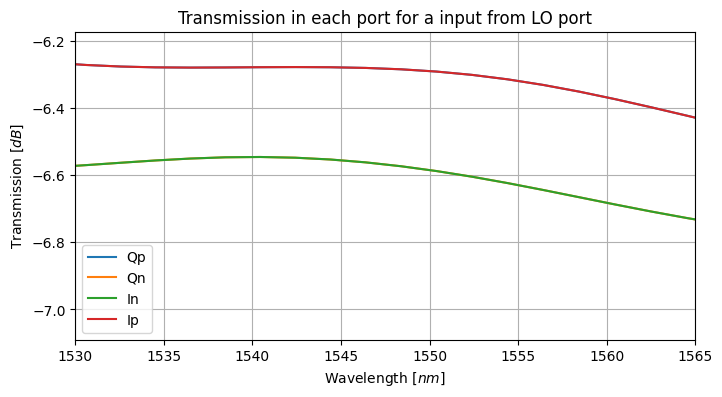

In [35]:
ports_list = [P_port_Qp_LO, P_port_Qn_LO, P_port_In_LO, P_port_Ip_LO]

k = 0
for port in ports_list:
    T_dB = 10*(np.log10(port) - np.log10(input_LO))
    plt.plot(central_wavelength/nm, T_dB, label = name_port_list[k])
    k += 1

plt.xlabel(r'Wavelength [$nm$]')
plt.ylabel(r'Transmission [$dB$]')
plt.xlim([1530, 1565])
plt.legend(loc = 'best')
plt.grid(True)
plt.title('Transmission in each port for a input from LO port')
plt.show()

### Analysing the Insertion Loss, CMRR and Imbalance ###

In [36]:
IL_Signal = 10*np.log10(input_Signal) - 10*np.log10(P_port_Qp_Signal + P_port_Qn_Signal + P_port_In_Signal + P_port_Ip_Signal)
IL_LO = 10*np.log10(input_LO) - 10*np.log10(P_port_Qp_LO + P_port_Qn_LO + P_port_In_LO + P_port_Ip_LO)

CMRR_Q_Signal = CMRR(P_port_Qp_Signal, P_port_Qn_Signal)
CMRR_I_Signal = CMRR(P_port_Ip_Signal, P_port_In_Signal)
CMRR_Q_LO = CMRR(P_port_Qp_LO, P_port_Qn_LO)
CMRR_I_LO = CMRR(P_port_Ip_LO, P_port_In_LO)

Imbalance_Q_Signal = Imbalance(P_port_Qp_Signal, P_port_Qn_Signal)
Imbalance_I_Signal = Imbalance(P_port_Ip_Signal, P_port_In_Signal)
Imbalance_Q_LO = Imbalance(P_port_Qp_LO, P_port_Qn_LO)
Imbalance_I_LO = Imbalance(P_port_Ip_LO, P_port_In_LO)

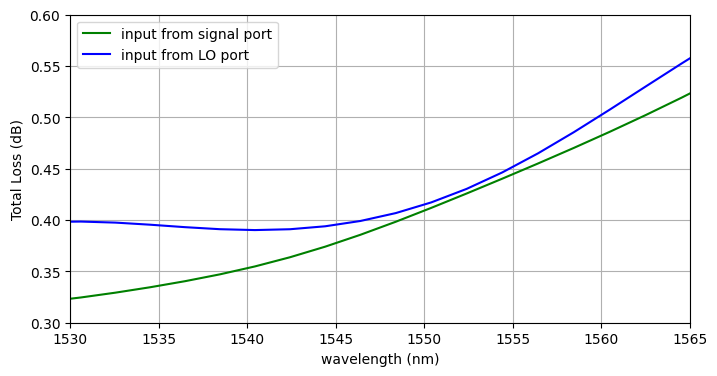

In [37]:
plt.plot(central_wavelength/nm, IL_Signal, label = 'input from signal port', color = 'green')
plt.plot(central_wavelength/nm, IL_LO, label = 'input from LO port', color = 'blue')
plt.xlabel('wavelength (nm)')
plt.ylabel('Total Loss (dB)')
plt.xlim([1530, 1565])
plt.ylim([0.3, 0.6])
plt.grid(True)
plt.legend()
plt.show()

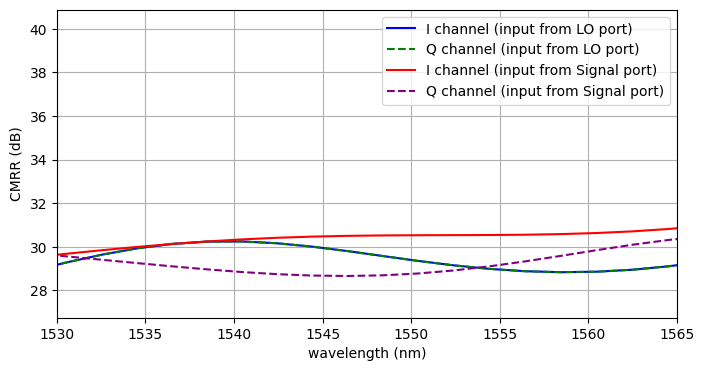

In [38]:
plt.plot(central_wavelength/nm, CMRR_I_LO, label = 'I channel (input from LO port)', color = 'blue')
plt.plot(central_wavelength/nm, CMRR_Q_LO, label = 'Q channel (input from LO port)', color = 'green', linestyle = '--')
plt.plot(central_wavelength/nm, CMRR_I_Signal, label = 'I channel (input from Signal port)', color = 'red')
plt.plot(central_wavelength/nm, CMRR_Q_Signal, label = 'Q channel (input from Signal port)', color = 'purple', linestyle = '--')
plt.xlabel('wavelength (nm)')
plt.ylabel('CMRR (dB)')
plt.xlim([1530, 1565])
#plt.ylim([28, 31.5])
plt.grid(True)
plt.legend()
plt.show()

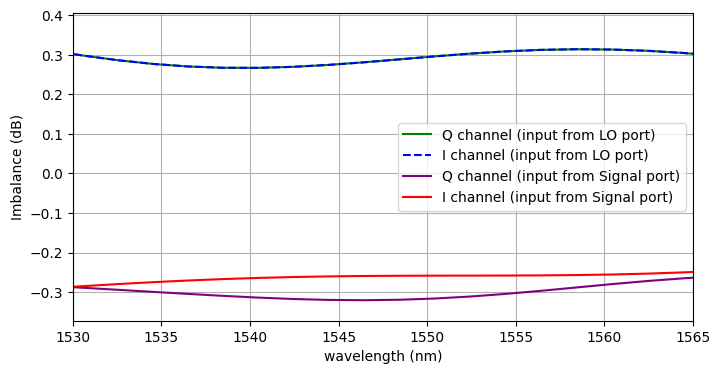

In [39]:
plt.plot(central_wavelength/nm, Imbalance_Q_LO, label = 'Q channel (input from LO port)', color = 'green')
plt.plot(central_wavelength/nm, Imbalance_I_LO, label = 'I channel (input from LO port)', color = 'blue', linestyle = '--')
plt.plot(central_wavelength/nm, Imbalance_Q_Signal, label = 'Q channel (input from Signal port)', color = 'purple')
plt.plot(central_wavelength/nm, Imbalance_I_Signal, label = 'I channel (input from Signal port)', color = 'red')
plt.xlabel('wavelength (nm)')
plt.ylabel('Imbalance (dB)')
plt.xlim([1530, 1565])
plt.grid(True)
plt.legend()
plt.show()

## Opreation with the Signal and LO ##

In [ ]:
fdtdApi.switchtolayout()

delta_f = 10*GHz

f0 = c/wavelength

delta_lambda = wavelength*(-1 + f0/(f0 + delta_f))

fdtdApi.setnamed('FDTD::ports', 'enabled', 0)

fdtdApi.addmode()
fdtdApi.set('name', 'LO source')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', 0)
fdtdApi.set('x span', 2*um)
fdtdApi.set('y', y_max_fdtd - 1.5*dL)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addmode()
fdtdApi.set('name', 'Signal source')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -(W5+W6)/2)
fdtdApi.set('x span', W5 + 1.9*W6)
fdtdApi.set('y', y_min_fdtd + 1.5*dL)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)
fdtdApi.set('center wavelength', wavelength + delta_lambda)

In [41]:
fdtdApi.run()

In [42]:
eField_x = np.squeeze(fdtdApi.getdata('profile_xy', 'Ex'))
eField_y = np.squeeze(fdtdApi.getdata('profile_xy', 'Ey'))
eField_z = np.squeeze(fdtdApi.getdata('profile_xy', 'Ez'))

eField_abs2 = np.abs(eField_x)**2 + np.abs(eField_y)**2 + np.abs(eField_z)**2
eField_abs = np.sqrt(eField_abs2)

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

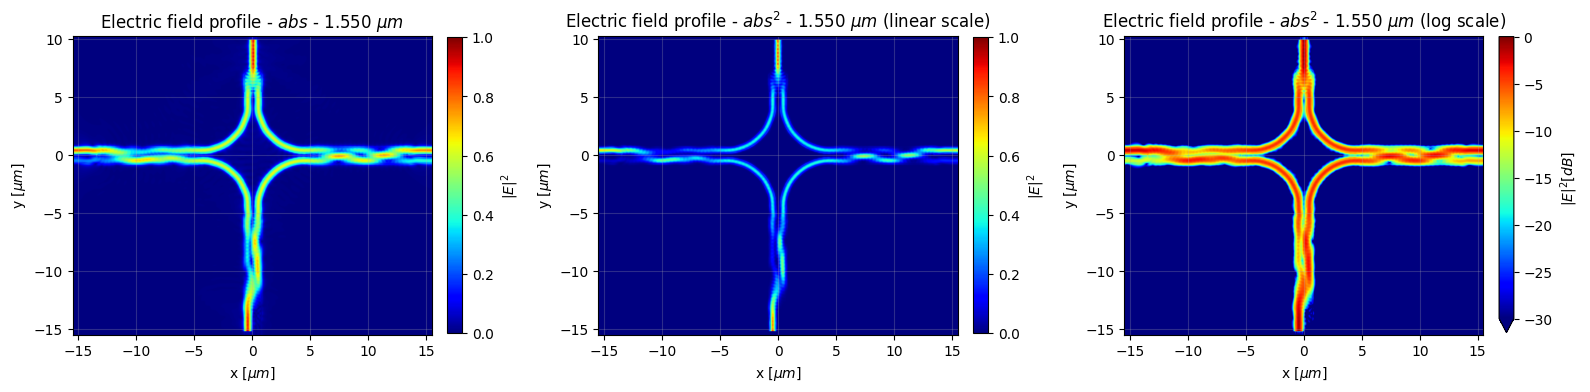

In [43]:
fig1, ax1 = plt.subplots(1,3,figsize=(16,4))

im1 = ax1[0].imshow(np.rot90(eField_abs[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
#ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im1,fraction = 0.038, pad =0.04, label = r'$|E|^2$')

ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'Electric field profile - $abs$ - %4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax1[0].grid(which='major', alpha = 0.25)

im2 = ax1[1].imshow(np.rot90(eField_abs2[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im2,fraction = 0.038, pad =0.04, label = r'$|E|^2$')

ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[1].grid(which='major', alpha = 0.25)

im3 = ax1[2].imshow(np.rot90(10*np.log10(eField_abs2[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = 'jet', aspect = 'equal')

colorbar = plt.colorbar(im3, fraction = 0.038, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax1[2].set_xlabel(r'x [$\mu m$]')
ax1[2].set_ylabel(r'y [$\mu m$]')
ax1[2].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[2].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

In [44]:
fdtdApi.switchtolayout()
fdtdApi.setnamed('Signal source', 'enabled', 0)
fdtdApi.setnamed('LO source', 'enabled', 0)
fdtdApi.setnamed('FDTD::ports', 'enabled', 1)
fdtdApi.close()